# Xây dựng pipeline hồi quy với tiền xử lý và giảm chiều PCA

**Họ và tên:** Lưu Ngọc Anh — **MSSV:** B26CHKH006
**Môn học:** Nhận dạng mẫu
**Hình thức:** Bài tập cá nhân
**Bộ dữ liệu:** Diabetes (có sẵn trong `scikit-learn`, không cần tải mạng)

## Mục tiêu

1. Xây dựng một **pipeline** hoàn chỉnh: tiền xử lý → (tuỳ chọn) giảm chiều PCA → mô hình hồi quy.
2. So sánh một **mô hình baseline** (dự đoán ngây thơ) với nhiều **mô hình hồi quy** khác nhau.
3. Kiểm tra **tác động của PCA** lên hiệu năng và độ ổn định của mô hình.
4. Chọn mô hình tốt nhất dựa trên **MAE, RMSE, R²** và **độ ổn định qua cross-validation** (CV).

## Bộ dữ liệu

`Diabetes` (scikit-learn) gồm 442 bệnh nhân, 10 đặc trưng số ban đầu (tuổi, giới tính,
chỉ số khối cơ thể `bmi`, huyết áp trung bình `bp`, 6 chỉ số xét nghiệm máu `s1`..`s6`)
và **biến mục tiêu liên tục** là mức độ tiến triển bệnh tiểu đường sau 1 năm (`target`).
Đây là bài toán **hồi quy** phù hợp với yêu cầu đề bài (target liên tục). Bộ dữ liệu này
được đóng gói sẵn bên trong thư viện `scikit-learn` (không cần tải qua mạng), nên notebook
chạy được ổn định trên mọi máy, kể cả khi không có kết nối Internet.

> **Lưu ý:** 10 đặc trưng gốc là khá ít chiều — PCA sẽ không có nhiều "đất diễn" nếu chỉ
> dùng nguyên bộ này. Ở Bước 4, ta sẽ mở rộng không gian đặc trưng bằng các đặc trưng
> tương tác/đa thức (polynomial features) để tạo ra một tình huống nhiều chiều, dư thừa
> hơn — gần với thực tế khi ta kết hợp nhiều đặc trưng thủ công — để việc so sánh
> "có PCA / không PCA" ở các bước sau thực sự có ý nghĩa quan sát được.

## Bước 0 — Import thư viện

Import các thư viện cần cho: xử lý dữ liệu (`pandas`, `numpy`), trực quan hóa
(`matplotlib`, `seaborn`) và học máy (`scikit-learn`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

import sklearn
print("Đã import xong thư viện. scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

Đã import xong thư viện. scikit-learn 1.9.1 | pandas 3.0.6


## Bước 1 — Nạp dữ liệu

Nạp bộ dữ liệu Diabetes trực tiếp từ `scikit-learn` dưới dạng `DataFrame`
(`as_frame=True`). Cột `target` là biến mục tiêu liên tục, 10 cột còn lại là đặc trưng
đầu vào. Pipeline ở các bước sau được viết tổng quát (tự nhận diện cột số / cột hạng mục)
nên có thể áp dụng lại cho bộ dữ liệu khác chỉ bằng cách thay bước nạp dữ liệu này.

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0000,-0.0000,0.0476,-0.1072,-0.0373,0.0054,0.0381,0.1107
sex,442.0000,0.0000,0.0476,-0.0446,-0.0446,-0.0446,0.0507,0.0507
bmi,442.0000,-0.0000,0.0476,-0.0903,-0.0342,-0.0073,0.0312,0.1706
bp,442.0000,-0.0000,0.0476,-0.1124,-0.0367,-0.0057,0.0356,0.1320
s1,442.0000,-0.0000,0.0476,-0.1268,-0.0342,-0.0043,0.0284,0.1539
s2,442.0000,0.0000,0.0476,-0.1156,-0.0304,-0.0038,0.0298,0.1988
s3,442.0000,-0.0000,0.0476,-0.1023,-0.0351,-0.0066,0.0293,0.1812
s4,442.0000,-0.0000,0.0476,-0.0764,-0.0395,-0.0026,0.0343,0.1852
s5,442.0000,0.0000,0.0476,-0.1261,-0.0332,-0.0019,0.0324,0.1336
s6,442.0000,0.0000,0.0476,-0.1378,-0.0332,-0.0011,0.0279,0.1356


## Bước 2 — Khám phá dữ liệu (EDA)

Kiểm tra nhanh: giá trị thiếu, kiểu dữ liệu, phân phối biến mục tiêu, và tương quan
giữa các đặc trưng — để hiểu dữ liệu trước khi xây pipeline.

In [4]:
print("Thông tin kiểu dữ liệu:")
df.info()
print("\nSố lượng giá trị thiếu trên mỗi cột:")
print(df.isna().sum())

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

Số lượng giá trị thiếu trên mỗi cột:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


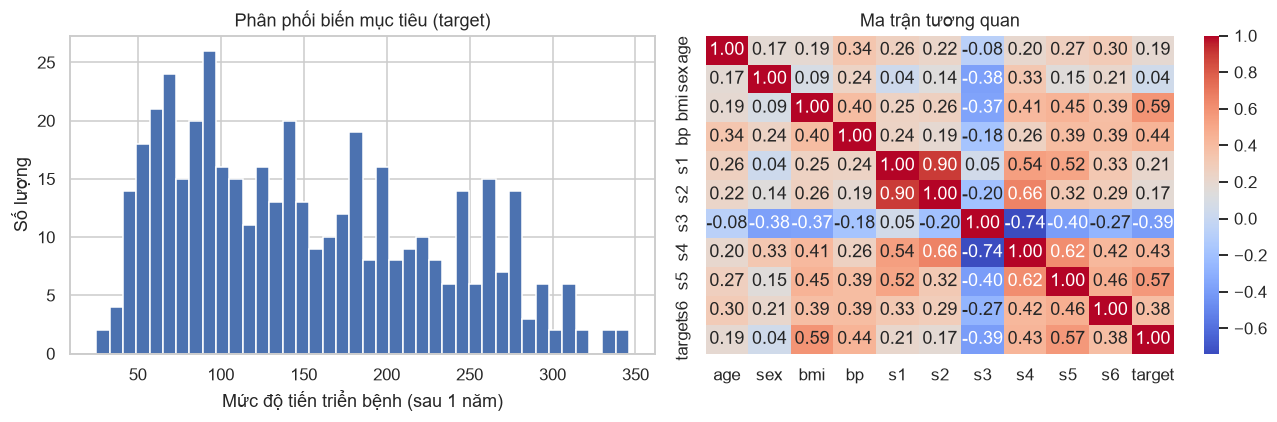

In [5]:
target_col = "target"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target_col], bins=40, color="#4C72B0")
axes[0].set_title("Phân phối biến mục tiêu (target)")
axes[0].set_xlabel("Mức độ tiến triển bệnh (sau 1 năm)")
axes[0].set_ylabel("Số lượng")

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], cbar=True)
axes[1].set_title("Ma trận tương quan")
plt.tight_layout()
plt.show()

**Nhận xét nhanh:** dữ liệu không có giá trị thiếu. Một số đặc trưng xét nghiệm máu
có tương quan khá mạnh với nhau (ví dụ `s1`/`s2` hay `s3`/`s4`), đây chính là kiểu dư
thừa thông tin (redundancy) mà PCA có thể tận dụng để nén lại thành ít chiều hơn.

## Bước 3 — Tách tập train / test

Tách dữ liệu thành tập huấn luyện (80%) và tập kiểm tra giữ lại (20%, hold-out test set).
Tập test **không được dùng** trong quá trình chọn mô hình / tinh chỉnh — chỉ dùng
một lần cuối cùng để đánh giá mô hình tốt nhất, tránh rò rỉ dữ liệu (data leakage).

In [6]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (353, 10)  Test: (89, 10)


## Bước 4 — Pipeline tiền xử lý

Dùng `ColumnTransformer` để tiền xử lý theo từng loại cột:
- Cột **số**: điền khuyết bằng median (`SimpleImputer`) → **mở rộng đặc trưng** bằng
  `PolynomialFeatures(degree=2)` (tạo thêm các số hạng bình phương và tương tác giữa
  các đặc trưng gốc, ví dụ `bmi²`, `bmi × bp`, ...) → chuẩn hóa (`StandardScaler`).
  Chuẩn hóa là **bắt buộc** trước khi dùng PCA, vì PCA nhạy với thang đo của dữ liệu.
- Cột **hạng mục** (categorical, nếu có): điền khuyết bằng mode rồi mã hóa one-hot.

Bước `PolynomialFeatures` không bắt buộc theo lý thuyết pipeline chuẩn, nhưng ở đây ta
chủ động thêm vào để biến 10 đặc trưng gốc (vốn ít chiều) thành 65 đặc trưng có độ dư
thừa cao — mô phỏng tình huống thực tế nhiều chiều/dư thừa, giúp phần so sánh "có PCA /
không PCA" ở các bước sau thể hiện rõ tác động của PCA hơn. Bộ dữ liệu Diabetes chỉ có
cột số, nhưng pipeline vẫn viết tổng quát để dễ tái sử dụng cho bộ dữ liệu khác có cả
cột hạng mục.

In [7]:
from sklearn.preprocessing import PolynomialFeatures

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Cột số:", numeric_features)
print("Cột hạng mục:", categorical_features if categorical_features else "(không có)")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

transformers = [("num", numeric_transformer, numeric_features)]

if categorical_features:
    from sklearn.preprocessing import OneHotEncoder
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    transformers.append(("cat", categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)
n_expanded = preprocessor.fit_transform(X_train).shape[1]
print(f"\nSố đặc trưng sau khi tiền xử lý (bao gồm polynomial): {n_expanded}")
print("Đã xây dựng xong bước tiền xử lý.")

Cột số: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Cột hạng mục: (không có)

Số đặc trưng sau khi tiền xử lý (bao gồm polynomial): 65
Đã xây dựng xong bước tiền xử lý.


## Bước 5 — Thiết lập đánh giá bằng Cross-Validation

Ta dùng **K-Fold cross-validation (K=5)** trên tập train để đánh giá mỗi mô hình:
mỗi mô hình được huấn luyện/kiểm tra 5 lần trên 5 phần dữ liệu khác nhau. Từ đó tính:

- **MAE** (Mean Absolute Error) — sai số tuyệt đối trung bình, càng nhỏ càng tốt.
- **RMSE** (Root Mean Squared Error) — phạt nặng hơn các sai số lớn, càng nhỏ càng tốt.
- **R²** — tỉ lệ phương sai được giải thích, càng gần 1 càng tốt.
- **Độ ổn định**: độ lệch chuẩn (std) của từng chỉ số qua 5 fold — std càng nhỏ,
  mô hình càng ổn định (ít nhạy với cách chia dữ liệu).

Hàm `evaluate_model` bên dưới sẽ được dùng lại cho mọi mô hình ở các bước sau.

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "RMSE": make_scorer(lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)), greater_is_better=False),
    "R2": make_scorer(r2_score),
}

def evaluate_model(name, pipeline, X=X_train, y=y_train):
    '''Chạy K-Fold CV cho 1 pipeline, trả về dict kết quả (mean ± std).'''
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {
        "Model": name,
        "MAE_mean": -results["test_MAE"].mean(),
        "MAE_std": results["test_MAE"].std(),
        "RMSE_mean": -results["test_RMSE"].mean(),
        "RMSE_std": results["test_RMSE"].std(),
        "R2_mean": results["test_R2"].mean(),
        "R2_std": results["test_R2"].std(),
    }
    return row

print("Đã định nghĩa hàm evaluate_model().")

Đã định nghĩa hàm evaluate_model().


## Bước 6 — Mô hình Baseline

Baseline đơn giản nhất cho bài toán hồi quy: luôn dự đoán bằng **giá trị trung bình**
của target trên tập train (`DummyRegressor(strategy="mean")`). Bất kỳ mô hình "thật"
nào cũng phải vượt qua được baseline này thì mới có ý nghĩa sử dụng.

In [9]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

baseline_result = evaluate_model("Baseline (mean)", baseline_pipeline)
pd.DataFrame([baseline_result])

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Baseline (mean),66.8673,5.6321,78.1336,5.6383,-0.0273,0.0244


## Bước 7 — So sánh các mô hình hồi quy (chưa dùng PCA)

Xây dựng pipeline `tiền xử lý → mô hình` cho nhiều mô hình hồi quy khác nhau, đại diện
cho các nhóm phương pháp: tuyến tính (Linear, Ridge, Lasso), phi tuyến dựa khoảng cách
(KNN), dựa cây (Random Forest, Gradient Boosting) và kernel (SVR). Mỗi mô hình được
đánh giá bằng 5-fold CV như hàm đã định nghĩa ở Bước 5.

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.01, max_iter=20000, random_state=RANDOM_STATE),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1),
}

results_no_pca = [baseline_result]
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    results_no_pca.append(evaluate_model(name, pipe))

df_no_pca = pd.DataFrame(results_no_pca).sort_values("RMSE_mean").reset_index(drop=True)
df_no_pca

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Random Forest,48.9097,3.5453,59.3248,2.6425,0.4041,0.0473
1,Ridge,47.9781,3.9011,60.4655,4.0041,0.3821,0.0531
2,KNN Regressor,49.8925,4.2229,60.6426,5.0241,0.3795,0.0595
3,Lasso,49.3390,4.3700,62.1781,4.3735,0.3466,0.0593
4,Gradient Boosting,50.7308,4.9739,62.4079,3.5583,0.3414,0.0527
5,Linear Regression,49.6294,4.3761,62.5048,4.4120,0.3388,0.0701
6,SVR (RBF),57.2861,5.0715,67.8017,5.7505,0.2251,0.0721
7,Baseline (mean),66.8673,5.6321,78.1336,5.6383,-0.0273,0.0244


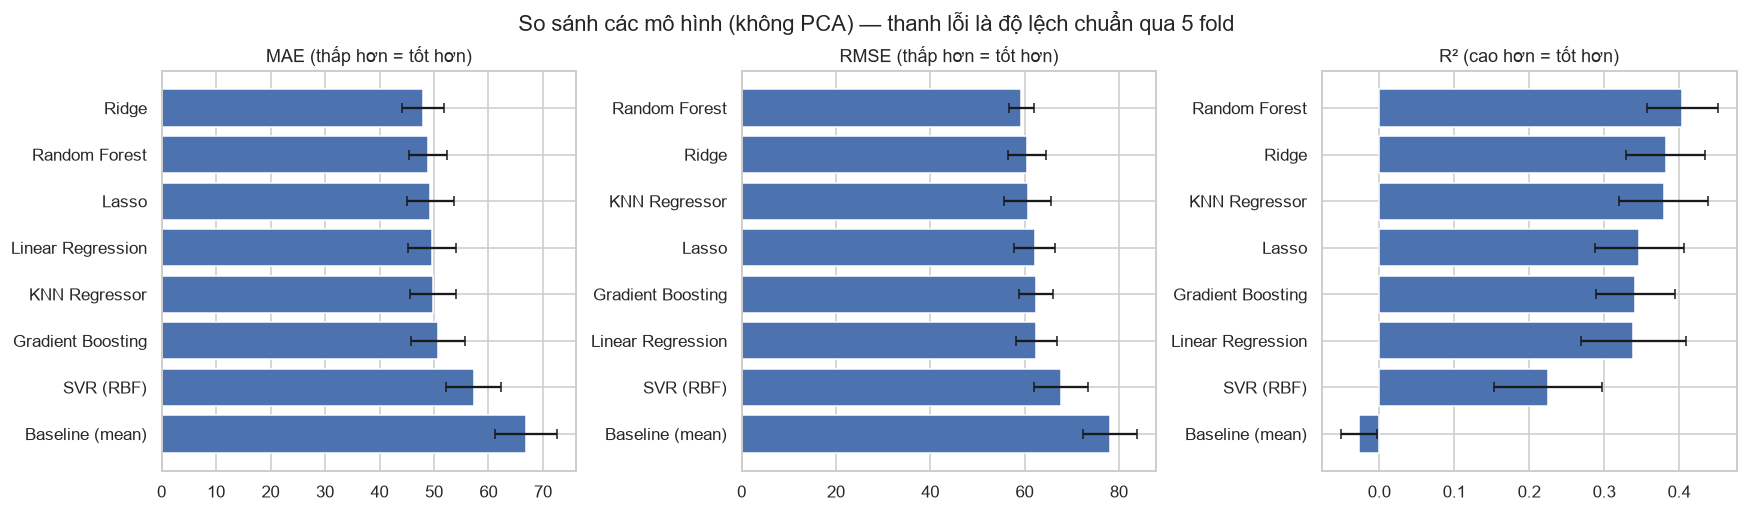

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics_plot = [("MAE_mean", "MAE_std", "MAE (thấp hơn = tốt hơn)"),
                ("RMSE_mean", "RMSE_std", "RMSE (thấp hơn = tốt hơn)"),
                ("R2_mean", "R2_std", "R² (cao hơn = tốt hơn)")]

for ax, (mcol, scol, title) in zip(axes, metrics_plot):
    order = df_no_pca.sort_values(mcol, ascending=(mcol != "R2_mean"))
    ax.barh(order["Model"], order[mcol], xerr=order[scol], color="#4C72B0", capsize=3)
    ax.set_title(title)
    ax.invert_yaxis()

plt.tight_layout()
plt.suptitle("So sánh các mô hình (không PCA) — thanh lỗi là độ lệch chuẩn qua 5 fold", y=1.03)
plt.show()

## Bước 8 — Thêm PCA vào pipeline và chọn số thành phần

Trước khi so sánh mô hình có/không PCA, ta xem **PCA cần giữ lại bao nhiêu thành phần**
để bảo toàn phần lớn thông tin (phương sai) của dữ liệu. Biểu đồ phương sai giải thích
tích lũy (cumulative explained variance) giúp chọn ngưỡng, ví dụ giữ ≥ 95% phương sai.

Số chiều sau tiền xử lý: 65
Số thành phần PCA cần để giữ ≥ 95% phương sai: 33


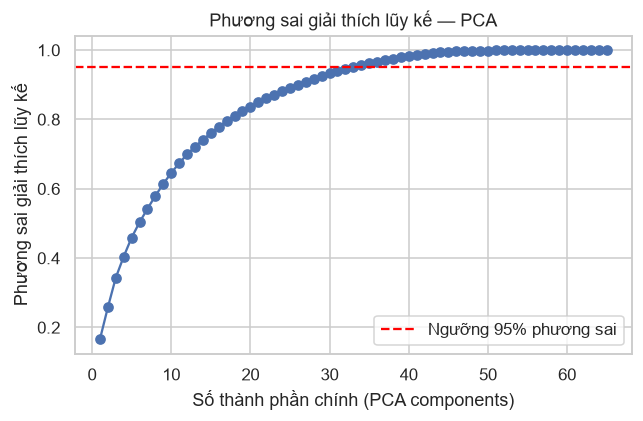

In [12]:
X_train_pre = preprocessor.fit_transform(X_train)
n_features_after_prep = X_train_pre.shape[1]

pca_full = PCA(n_components=n_features_after_prep, random_state=RANDOM_STATE)
pca_full.fit(X_train_pre)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="Ngưỡng 95% phương sai")
plt.xlabel("Số thành phần chính (PCA components)")
plt.ylabel("Phương sai giải thích lũy kế")
plt.title("Phương sai giải thích lũy kế — PCA")
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Số chiều sau tiền xử lý: {n_features_after_prep}")
print(f"Số thành phần PCA cần để giữ ≥ 95% phương sai: {n_components_95}")

**Lưu ý:** nhờ bước `PolynomialFeatures` ở Bước 4, số chiều sau tiền xử lý đã tăng từ
10 lên 65 đặc trưng — và vì nhiều đặc trưng trong số đó là tổ hợp/tương tác của cùng
một vài biến gốc nên có độ **dư thừa (redundancy) cao**. Đây là điều kiện lý tưởng để
PCA phát huy tác dụng: nén 65 chiều dư thừa xuống chỉ còn vài chục thành phần chính mà
vẫn giữ được phần lớn thông tin. Tuy vậy, mức độ PCA giúp ích **nhiều hay ít vẫn tuỳ
vào từng mô hình** (ví dụ mô hình khoảng cách/kernel như KNN, SVR thường nhạy với số
chiều hơn mô hình tuyến tính hay mô hình dựa cây) — đó chính là điều ta sẽ kiểm chứng
ở Bước 9 và 10.

## Bước 9 — So sánh các mô hình *có* PCA

Lặp lại đúng các mô hình ở Bước 7, nhưng chèn thêm bước `PCA(n_components=n_components_95)`
vào giữa tiền xử lý và mô hình: `tiền xử lý → PCA → mô hình`.

In [13]:
results_pca = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("pca", PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
        ("model", model),
    ])
    results_pca.append(evaluate_model(name + " + PCA", pipe))

df_pca = pd.DataFrame(results_pca).sort_values("RMSE_mean").reset_index(drop=True)
df_pca

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Ridge + PCA,46.0476,1.3039,57.2646,2.4022,0.4405,0.0823
1,Lasso + PCA,46.0539,1.2967,57.2800,2.4187,0.4401,0.0825
2,Linear Regression + PCA,46.0550,1.2961,57.2825,2.4295,0.4401,0.0826
3,Gradient Boosting + PCA,49.0794,3.0886,60.1033,3.7852,0.3860,0.0833
4,KNN Regressor + PCA,50.1409,4.2337,60.9045,4.6987,0.3754,0.0372
5,Random Forest + PCA,50.3039,3.8654,61.6540,5.3282,0.3555,0.0983
6,SVR (RBF) + PCA,56.7816,4.8461,67.2957,5.6157,0.2364,0.0714


## Bước 10 — So sánh trực tiếp: có PCA vs. không PCA

Ghép hai bảng kết quả lại theo từng mô hình để thấy rõ PCA giúp ích hay gây hại cho
từng loại mô hình, đặc biệt chú ý đến **RMSE, R²** và **độ ổn định (std)**.

In [14]:
compare = df_no_pca[df_no_pca["Model"] != "Baseline (mean)"].copy()
compare["Model_base"] = compare["Model"]
pca_compare = df_pca.copy()
pca_compare["Model_base"] = pca_compare["Model"].str.replace(" + PCA", "", regex=False)

merged = compare.merge(
    pca_compare, on="Model_base", suffixes=("_noPCA", "_PCA")
)[[
    "Model_base",
    "RMSE_mean_noPCA", "RMSE_mean_PCA",
    "R2_mean_noPCA", "R2_mean_PCA",
    "RMSE_std_noPCA", "RMSE_std_PCA",
]]
merged["RMSE_thay_doi(%)"] = (merged["RMSE_mean_PCA"] - merged["RMSE_mean_noPCA"]) / merged["RMSE_mean_noPCA"] * 100
merged = merged.sort_values("RMSE_mean_noPCA")
merged

,Model_base,RMSE_mean_noPCA,RMSE_mean_PCA,R2_mean_noPCA,R2_mean_PCA,RMSE_std_noPCA,RMSE_std_PCA,RMSE_thay_doi(%)
0,Random Forest,59.3248,61.6540,0.4041,0.3555,2.6425,5.3282,3.9262
1,Ridge,60.4655,57.2646,0.3821,0.4405,4.0041,2.4022,-5.2938
2,KNN Regressor,60.6426,60.9045,0.3795,0.3754,5.0241,4.6987,0.4319
3,Lasso,62.1781,57.2800,0.3466,0.4401,4.3735,2.4187,-7.8776
4,Gradient Boosting,62.4079,60.1033,0.3414,0.3860,3.5583,3.7852,-3.6927
5,Linear Regression,62.5048,57.2825,0.3388,0.4401,4.4120,2.4295,-8.3550
6,SVR (RBF),67.8017,67.2957,0.2251,0.2364,5.7505,5.6157,-0.7462


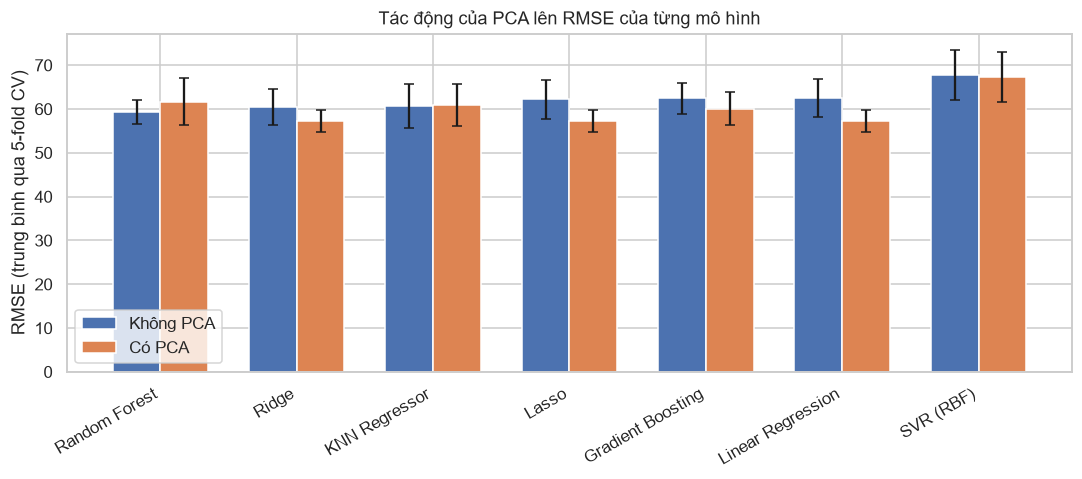

In [15]:
x = np.arange(len(merged))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width/2, merged["RMSE_mean_noPCA"], width, yerr=merged["RMSE_std_noPCA"],
       label="Không PCA", color="#4C72B0", capsize=3)
ax.bar(x + width/2, merged["RMSE_mean_PCA"], width, yerr=merged["RMSE_std_PCA"],
       label="Có PCA", color="#DD8452", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels(merged["Model_base"], rotation=30, ha="right")
ax.set_ylabel("RMSE (trung bình qua 5-fold CV)")
ax.set_title("Tác động của PCA lên RMSE của từng mô hình")
ax.legend()
plt.tight_layout()
plt.show()

## Bước 11 — Chọn mô hình tốt nhất

Tiêu chí chọn mô hình:
1. **RMSE / MAE thấp** và **R² cao** (trung bình qua CV).
2. **Độ ổn định cao**: độ lệch chuẩn (std) của các chỉ số qua 5 fold càng nhỏ càng tốt
   — mô hình không nên "may rủi" phụ thuộc vào cách chia dữ liệu.
3. So sánh cả phiên bản có và không có PCA để quyết định có nên giữ PCA hay không.

Bảng dưới đây gộp toàn bộ kết quả (baseline, có/không PCA) và xếp hạng theo RMSE.

In [16]:
all_results = pd.concat([df_no_pca, df_pca], ignore_index=True)
all_results_sorted = all_results.sort_values("RMSE_mean").reset_index(drop=True)
all_results_sorted

,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Ridge + PCA,46.0476,1.3039,57.2646,2.4022,0.4405,0.0823
1,Lasso + PCA,46.0539,1.2967,57.2800,2.4187,0.4401,0.0825
2,Linear Regression + PCA,46.0550,1.2961,57.2825,2.4295,0.4401,0.0826
3,Random Forest,48.9097,3.5453,59.3248,2.6425,0.4041,0.0473
4,Gradient Boosting + PCA,49.0794,3.0886,60.1033,3.7852,0.3860,0.0833
5,Ridge,47.9781,3.9011,60.4655,4.0041,0.3821,0.0531
6,KNN Regressor,49.8925,4.2229,60.6426,5.0241,0.3795,0.0595
7,KNN Regressor + PCA,50.1409,4.2337,60.9045,4.6987,0.3754,0.0372
8,Random Forest + PCA,50.3039,3.8654,61.6540,5.3282,0.3555,0.0983
9,Lasso,49.3390,4.3700,62.1781,4.3735,0.3466,0.0593


In [17]:
best_row = all_results_sorted.iloc[0]
print("Mô hình tốt nhất theo RMSE (CV trên tập train):")
print(best_row)

Mô hình tốt nhất theo RMSE (CV trên tập train):
Model        Ridge + PCA
MAE_mean         46.0476
MAE_std           1.3039
RMSE_mean        57.2646
RMSE_std          2.4022
R2_mean           0.4405
R2_std            0.0823
Name: 0, dtype: object


## Bước 12 — Tinh chỉnh siêu tham số cho mô hình #1

Thay vì hard-code sẵn một mô hình, ta lấy đúng mô hình đang **xếp hạng #1** ở bảng
Bước 11 (`best_row`) — bao gồm cả việc nó có dùng PCA hay không — rồi tinh chỉnh thêm
một vài siêu tham số quan trọng nhất bằng `GridSearchCV`, vẫn dùng cùng chiến lược
5-fold CV để tránh overfitting vào tập train. Cách làm này đảm bảo bước tinh chỉnh
luôn khớp với kết quả xếp hạng thực tế ở Bước 11.

In [18]:
# Lưới siêu tham số cho từng loại mô hình
param_grids = {
    "Linear Regression": {"model__fit_intercept": [True, False]},
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0]},
    "Lasso": {"model__alpha": [0.001, 0.01, 0.1, 1.0]},
    "KNN Regressor": {"model__n_neighbors": [5, 10, 15, 20], "model__weights": ["uniform", "distance"]},
    "Random Forest": {"model__n_estimators": [200, 400], "model__max_depth": [None, 12, 20], "model__min_samples_leaf": [1, 2, 4]},
    "Gradient Boosting": {"model__n_estimators": [100, 200], "model__max_depth": [2, 3, 4], "model__learning_rate": [0.05, 0.1]},
    "SVR (RBF)": {"model__C": [1, 10, 50], "model__epsilon": [0.05, 0.1, 0.2]},
}

best_model_label = best_row["Model"]              # ví dụ: "Ridge + PCA"
use_pca = best_model_label.endswith(" + PCA")
base_model_name = best_model_label.replace(" + PCA", "")

steps = [("preprocessor", preprocessor)]
if use_pca:
    steps.append(("pca", PCA(n_components=n_components_95, random_state=RANDOM_STATE)))
steps.append(("model", models[base_model_name]))
best_pipeline = Pipeline(steps=steps)

param_grid = param_grids[base_model_name]

print(f"Mô hình #1 được chọn để tinh chỉnh: {best_model_label}")
print(f"Lưới siêu tham số: {param_grid}")

grid_search = GridSearchCV(
    best_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("\nSiêu tham số tốt nhất:", grid_search.best_params_)
print(f"RMSE tốt nhất (CV): {-grid_search.best_score_:.4f}")

Mô hình #1 được chọn để tinh chỉnh: Ridge + PCA
Lưới siêu tham số: {'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}

Siêu tham số tốt nhất: {'model__alpha': 50.0}
RMSE tốt nhất (CV): 56.9720


## Bước 13 — Đánh giá cuối cùng trên tập test (hold-out)

Đây là bước **duy nhất** dùng tới tập test đã tách riêng từ Bước 3. Huấn luyện lại
mô hình tốt nhất (với siêu tham số đã tinh chỉnh) trên **toàn bộ tập train**, rồi
đánh giá một lần trên tập test để có con số cuối cùng, khách quan.

In [19]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

# Đánh giá lại baseline trên tập test để đối chiếu
baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
base_mae = mean_absolute_error(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_r2 = r2_score(y_test, y_pred_base)

summary = pd.DataFrame([
    {"Model": "Baseline (mean)", "MAE": base_mae, "RMSE": base_rmse, "R2": base_r2},
    {"Model": best_model_label + " (tuned)", "MAE": final_mae, "RMSE": final_rmse, "R2": final_r2},
])
summary

,Model,MAE,RMSE,R2
0,Baseline (mean),64.0065,73.2225,-0.0120
1,Ridge + PCA (tuned),44.7379,55.3385,0.4220


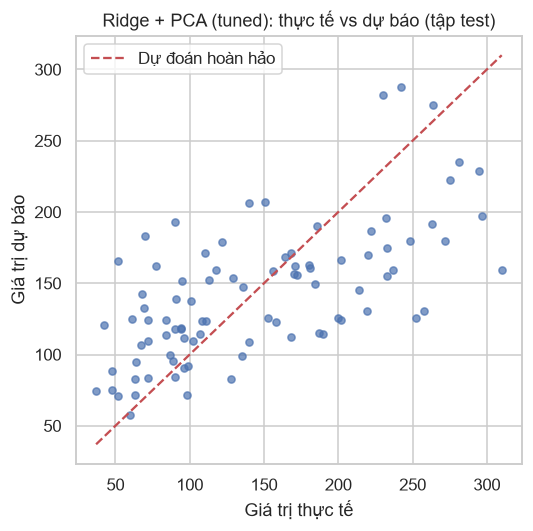

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, alpha=0.7, s=22, color="#4C72B0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="Dự đoán hoàn hảo")
ax.set_xlabel("Giá trị thực tế")
ax.set_ylabel("Giá trị dự báo")
ax.set_title(f"{best_model_label} (tuned): thực tế vs dự báo (tập test)")
ax.legend()
plt.tight_layout()
plt.show()

## Bước 14 — Kết luận

**1. Mô hình tốt nhất.** Qua 5-fold CV trên tập train, **Ridge + PCA** (33 thành phần,
giữ ≥ 95% phương sai) xếp hạng #1 với MAE ≈ 46,05, RMSE ≈ 57,26, R² ≈ 0,44. Lasso + PCA
và Linear Regression + PCA cho kết quả gần như trùng khớp (chênh lệch RMSE < 0,02, rất
nhỏ so với độ lệch chuẩn ≈ 2,4 giữa các fold), nên thực chất ba mô hình tuyến tính + PCA
là ngang nhau; Ridge được giữ lại vì có tham số điều chuẩn L2 để tinh chỉnh tiếp. Về độ
ổn định, nhóm này có std MAE (≈ 1,3) và std RMSE (≈ 2,4) **thấp nhất** trong mọi cấu
hình; riêng std R² (≈ 0,082) lại cao hơn Random Forest không PCA (≈ 0,047), vì R² còn
phụ thuộc phương sai của target trong từng fold. Sau khi tinh chỉnh bằng `GridSearchCV`
(`alpha = 50`), mô hình đạt trên tập test: **MAE = 44,74, RMSE = 55,34, R² = 0,422**.

**2. Tác động của PCA phụ thuộc vào từng mô hình.**
- *Mô hình tuyến tính* hưởng lợi rõ nhất (Linear Regression −8,4% RMSE, Lasso −7,9%,
  Ridge −5,3%): 65 đặc trưng đa thức có đa cộng tuyến mạnh; PCA tạo ra các thành phần
  trực giao và loại bỏ 32 hướng có phương sai nhỏ (phần lớn là nhiễu), tác dụng tương tự
  một dạng điều chuẩn.
- *Gradient Boosting* cũng cải thiện (≈ −3,7% RMSE), trong khi *Random Forest* kém đi
  (+3,9% RMSE, std tăng gần gấp đôi). Cây quyết định chia dữ liệu theo ngưỡng trên từng
  đặc trưng riêng lẻ; sau PCA mỗi thành phần là tổ hợp tuyến tính của mọi đặc trưng nên
  các ngưỡng "tự nhiên" (ví dụ theo `bmi`, `s5`) bị trộn lẫn. Kết quả trái chiều giữa hai
  mô hình cây cho thấy không thể kết luận chung rằng "PCA không có lợi cho mô hình cây".
- *KNN* (+0,4%) và *SVR* (−0,7%) gần như không đổi: khi giữ 95% phương sai, khoảng cách
  Euclid giữa các mẫu đã chuẩn hóa được bảo toàn gần như nguyên vẹn, nên hai mô hình dựa
  khoảng cách/kernel này nhận đầu vào gần tương đương.

**3. So với baseline.** Trên tập test, mô hình được chọn giảm RMSE từ 73,22 xuống 55,34
(**−24,4%**), giảm MAE từ 64,01 xuống 44,74 (**−30,1%**) và tăng R² từ −0,01 lên 0,42.

**4. Hạn chế và hướng cải thiện.**
- Số thành phần PCA (33) được chọn trên toàn bộ tập train trước khi chạy CV nên có rò rỉ
  thông tin nhẹ vào các fold; cách chặt chẽ hơn là dùng `PCA(n_components=0.95)` ngay
  trong pipeline hoặc đưa `n_components` vào lưới `GridSearchCV`.
- Chỉ mô hình xếp hạng #1 được tinh chỉnh siêu tham số; các mô hình còn lại dùng tham
  số mặc định (ví dụ Lasso với `alpha = 0,01` gần như không điều chuẩn), nên so sánh
  giữa các nhóm mô hình chưa hoàn toàn công bằng.
- Dữ liệu nhỏ (442 mẫu, tập test chỉ 89 mẫu) nên kết quả có thể dao động theo cách chia;
  có thể dùng repeated / nested cross-validation để ước lượng tin cậy hơn.
- R² ≈ 0,44 cho thấy phần lớn phương sai của target vẫn chưa được giải thích; có thể thử
  thêm lựa chọn đặc trưng, xử lý ngoại lai hoặc các mô hình phi tuyến được tinh chỉnh kỹ.